In [21]:
import cv2
from pathlib import Path
import pandas as pd
import numpy as np
from skimage.draw import polygon
import matplotlib.pyplot as plt
import sys

In [22]:
# path_dice_ensemble = '/home/paul/workspace/year1/projects/ped_unc/echonet/exp/results_data/ensemble/segmentation_results_ensemble_dice_adults.csv'
# path_dice_phiseg = '/home/paul/workspace/year1/projects/ped_unc/echonet/exp/results_data/phiseg/segmentation_results_phiseg_dice_adults.csv'
# path_dice_vids = '/home/paul/workspace/year1/projects/ped_unc/echonet/exp/results_data/vids/segmentation_results_vids_dice_adults_3.csv'

# combined, no augmentation
path_dice_ensemble_norm = '/home/paul/workspace/year1/projects/ped_unc/echonet/exp/results_data/ens_comb/segmentation_results_ensemble_dice_adults_norm.csv'
path_dice_phiseg_norm = '/home/paul/workspace/year1/projects/ped_unc/echonet/exp/results_data/phiseg_comb/segmentation_results_phiseg_dice_norm.csv'
path_dice_vids_norm = '/home/paul/workspace/year1/projects/ped_unc/echonet/exp/results_data/vids_comb/segmentation_results_vids_dice_norm.csv'

# combined, no augmentation, big dataset
path_dice_ensemble_big = '/home/paul/workspace/year1/projects/ped_unc/echonet/exp/results_data/ens_comb/big_ds/segmentation_results_ensemble_dice_adults_norm.csv'
path_dice_phiseg_big = '/home/paul/workspace/year1/projects/ped_unc/echonet/exp/results_data/phiseg_comb/big_ds/segmentation_results_phiseg_dice_norm.csv'
path_dice_vids_big = '/home/paul/workspace/year1/projects/ped_unc/echonet/exp/results_data/vids_comb/big_ds/segmentation_results_vids_dice_norm.csv'

# combined, with augmentation
# path_dice_ensemble = '/home/paul/workspace/year1/projects/ped_unc/echonet/exp/results_data/ens_comb/segmentation_results_ensemble_dice_adults_aug.csv'
# path_dice_phiseg = '/home/paul/workspace/year1/projects/ped_unc/echonet/exp/results_data/phiseg_comb/segmentation_results_phiseg_dice_augm.csv'
# path_dice_vids = '/home/paul/workspace/year1/projects/ped_unc/echonet/exp/results_data/vids_comb/segmentation_results_vids_dice_augm.csv'

df_ens = pd.concat([pd.read_csv(path_dice_ensemble_norm), pd.read_csv(path_dice_ensemble_big)], ignore_index=True)
df_phiseg = pd.concat([pd.read_csv(path_dice_phiseg_norm), pd.read_csv(path_dice_phiseg_big)], ignore_index=True)
df_vids = pd.concat([pd.read_csv(path_dice_vids_norm), pd.read_csv(path_dice_vids_big)], ignore_index=True)

In [23]:
df_vids.head()

,filename,age,phase,dice
0,CR32a7581-CR32a9b0b-000051.h5,18,ed,0.930417
1,CR32a7581-CR32a9b0b-000051.h5,18,es,0.951382
2,CR32a9679-CR3dcb61c-000048.h5,18,ed,0.800096
3,CR32a9679-CR3dcb61c-000048.h5,18,es,0.855096
4,CR3dcac3c-CR3dcaf03-000043.h5,15,ed,0.947396


In [24]:
# Define age group bins and labels
bins = [-np.inf, 0, 2, 5, 12, 18]
labels = ['infant', 'toddler', 'preschooler', 'school age', 'teenager']

# Create age group column
df_ens['age_group'] = pd.cut(df_ens['age'], bins=bins, labels=labels, right=True)
df_phiseg['age_group'] = pd.cut(df_phiseg['age'], bins=bins, labels=labels, right=True)
df_vids['age_group'] = pd.cut(df_vids['age'], bins=bins, labels=labels, right=True)

# Compute mean and std of dice per age group
stats_ens = df_ens.groupby('age_group', observed=False)['dice'].agg(['mean', 'std', 'count'])
stats_ens.columns = ['mean_dice', 'std_dice', 'n_samples']

stats_phiseg = df_phiseg.groupby('age_group', observed=False)['dice'].agg(['mean', 'std', 'count'])
stats_phiseg.columns = ['mean_dice', 'std_dice', 'n_samples']

stats_vids = df_vids.groupby('age_group', observed=False)['dice'].agg(['mean', 'std', 'count'])
stats_vids.columns = ['mean_dice', 'std_dice', 'n_samples']




print(stats_ens)
print(stats_phiseg)
print(stats_vids)

             mean_dice  std_dice  n_samples
age_group                                  
infant        0.852986  0.164012         46
toddler       0.914695  0.051684         86
preschooler   0.916796  0.045897        138
school age    0.914460  0.041840        444
teenager      0.910329  0.045152        512
             mean_dice  std_dice  n_samples
age_group                                  
infant        0.845501  0.169794         46
toddler       0.909246  0.047308         86
preschooler   0.912307  0.050731        138
school age    0.911174  0.041440        444
teenager      0.904769  0.049644        512
             mean_dice  std_dice  n_samples
age_group                                  
infant        0.854249  0.166781         46
toddler       0.909436  0.051992         86
preschooler   0.914383  0.045888        138
school age    0.907940  0.049306        444
teenager      0.904807  0.049779        512


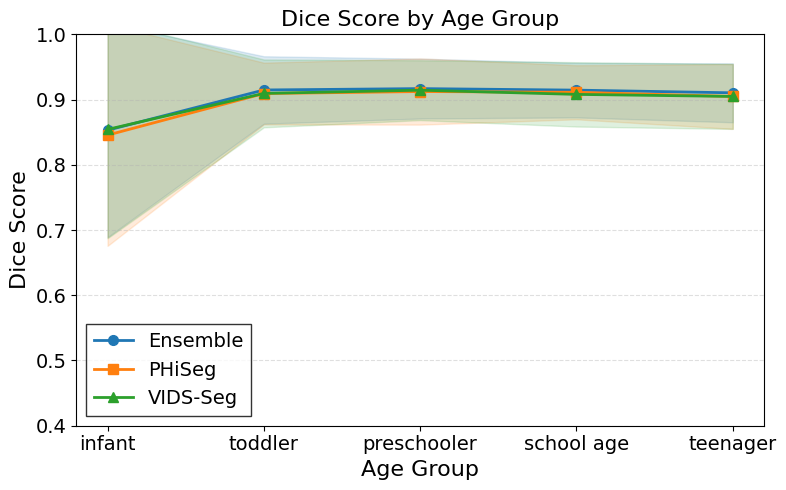

In [25]:
fig, ax = plt.subplots(figsize=(8, 5))

age_groups = stats_ens.index.tolist()
x = np.arange(len(age_groups))

models = {
    'Ensemble': (stats_ens, '#1f77b4', 'o'),
    'PHiSeg':   (stats_phiseg, '#ff7f0e', 's'),
    'VIDS-Seg':     (stats_vids, '#2ca02c', '^'),
}

for name, (stats, color, marker) in models.items():
    mean = stats['mean_dice'].values
    std  = stats['std_dice'].values

    # shaded std band
    ax.fill_between(x, mean - std, mean + std, alpha=0.15, color=color)
    # mean line
    ax.plot(x, mean, marker=marker, markersize=7, linewidth=2,
            color=color, label=name)

ax.set_xticks(x)
ax.set_xticklabels(age_groups, fontsize=16)
ax.set_xlabel('Age Group', fontsize=16)
ax.set_ylabel('Dice Score', fontsize=16)
ax.set_title('Dice Score by Age Group', fontsize=16)
ax.legend(fontsize=14, frameon=True, fancybox=False, edgecolor='black')
ax.set_ylim(0.4, 1.0)
ax.tick_params(labelsize=14)
ax.grid(axis='y', linestyle='--', alpha=0.4)

# add sample counts along the bottom
# for i, n in enumerate(stats_ens['n_samples'].values):
#     ax.text(i, ax.get_ylim()[0] + 0.01, f'n={n}', ha='center',
#             fontsize=9, color='grey')

fig.tight_layout()
# plt.savefig('dice_by_age_group.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [26]:
# now for ejection fraction
# path_ef_ens = '/home/paul/workspace/year1/projects/ped_unc/echonet/exp/results_data/ensemble/results_ensemble_ef_adults.csv'
# path_ef_phiseg = '/home/paul/workspace/year1/projects/ped_unc/echonet/exp/results_data/phiseg/results_phiseg_ef_adults.csv'
# path_ef_vids = '/home/paul/workspace/year1/projects/ped_unc/echonet/exp/results_data/vids/results_vids_ef_adults_3.csv'

# for the old plot
path_ef_ens_norm = '/home/paul/workspace/year1/projects/ped_unc/echonet/exp/results_data/ens_comb/results_ensemble_ef_adults_norm.csv'
path_ef_phiseg_norm = '/home/paul/workspace/year1/projects/ped_unc/echonet/exp/results_data/phiseg_comb/results_phiseg_ef_norm.csv'
path_ef_vids_norm = '/home/paul/workspace/year1/projects/ped_unc/echonet/exp/results_data/vids_comb/results_vids_ef_norm.csv'

# combined, no augmentation, big dataset
path_ef_ens_big = '/home/paul/workspace/year1/projects/ped_unc/echonet/exp/results_data/ens_comb/big_ds/results_ensemble_ef_adults_norm.csv'
path_ef_phiseg_big = '/home/paul/workspace/year1/projects/ped_unc/echonet/exp/results_data/phiseg_comb/big_ds/results_phiseg_ef_norm.csv'
path_ef_vids_big = '/home/paul/workspace/year1/projects/ped_unc/echonet/exp/results_data/vids_comb/big_ds/results_vids_ef_norm.csv'

# path_ef_ens = '/home/paul/workspace/year1/projects/ped_unc/echonet/exp/results_data/ens_comb/results_ensemble_ef_adults_aug.csv'
# path_ef_phiseg = '/home/paul/workspace/year1/projects/ped_unc/echonet/exp/results_data/phiseg_comb/results_phiseg_ef_augm.csv'
# path_ef_vids = '/home/paul/workspace/year1/projects/ped_unc/echonet/exp/results_data/vids_comb/results_vids_ef_augm.csv'

df_ef_ens = pd.concat([pd.read_csv(path_ef_ens_norm), pd.read_csv(path_ef_ens_big)], ignore_index=True)
df_ef_phiseg = pd.concat([pd.read_csv(path_ef_phiseg_norm), pd.read_csv(path_ef_phiseg_big)], ignore_index=True)
df_ef_vids = pd.concat([pd.read_csv(path_ef_vids_norm), pd.read_csv(path_ef_vids_big)], ignore_index=True)

In [27]:
# Create age group column
df_ef_ens['age_group'] = pd.cut(df_ef_ens['age'], bins=bins, labels=labels, right=True)

# Compute error metrics per sample
df_ef_ens['error'] = df_ef_ens['mean_ef_pred'] - df_ef_ens['gt_ef']  # signed error
df_ef_ens['abs_error'] = np.abs(df_ef_ens['error'])  # absolute error
df_ef_ens['squared_error'] = df_ef_ens['error'] ** 2  # squared error

# Compute stats per age group
stats_ens = df_ef_ens.groupby('age_group', observed=False).agg(
    mae=('abs_error', 'mean'),             # Mean Absolute Error
    mae_std=('abs_error', 'std'),          # Std of Absolute Error
    correlation=('error', lambda x: df_ef_ens.loc[x.index, 'mean_ef_pred'].corr(
                                    df_ef_ens.loc[x.index, 'gt_ef'])),
    n_samples=('filename', 'count')
)

# Create age group column
df_ef_phiseg['age_group'] = pd.cut(df_ef_phiseg['age'], bins=bins, labels=labels, right=True)

# Compute error metrics per sample
df_ef_phiseg['error'] = df_ef_phiseg['mean_ef_pred'] - df_ef_phiseg['gt_ef']  # signed error
df_ef_phiseg['abs_error'] = np.abs(df_ef_phiseg['error'])  # absolute error
df_ef_phiseg['squared_error'] = df_ef_phiseg['error'] ** 2  # squared error

# Compute stats per age group
stats_phiseg = df_ef_phiseg.groupby('age_group', observed=False).agg(
    mae=('abs_error', 'mean'),             # Mean Absolute Error
    mae_std=('abs_error', 'std'),          # Std of Absolute Error
    correlation=('error', lambda x: df_ef_phiseg.loc[x.index, 'mean_ef_pred'].corr(
                                    df_ef_phiseg.loc[x.index, 'gt_ef'])),
    n_samples=('filename', 'count')
)

# Create age group column
df_ef_vids['age_group'] = pd.cut(df_ef_vids['age'], bins=bins, labels=labels, right=True)

# Compute error metrics per sample
df_ef_vids['error'] = df_ef_vids['mean_ef_pred'] - df_ef_vids['gt_ef']  # signed error
df_ef_vids['abs_error'] = np.abs(df_ef_vids['error'])  # absolute error
df_ef_vids['squared_error'] = df_ef_vids['error'] ** 2  # squared error

# Compute stats per age group
stats_vids = df_ef_vids.groupby('age_group', observed=False).agg(
    mae=('abs_error', 'mean'),             # Mean Absolute Error
    mae_std=('abs_error', 'std'),          # Std of Absolute Error
    correlation=('error', lambda x: df_ef_vids.loc[x.index, 'mean_ef_pred'].corr(
                                    df_ef_vids.loc[x.index, 'gt_ef'])),
    n_samples=('filename', 'count')
)

print(stats_ens.round(3))
print(stats_phiseg.round(3))
print(stats_vids.round(3))

                mae  mae_std  correlation  n_samples
age_group                                           
infant       15.922   23.678        0.532         23
toddler       9.757   10.356        0.729         43
preschooler   7.074    6.255        0.458         69
school age    7.460    5.874        0.618        222
teenager      8.916    8.868        0.648        256
                mae  mae_std  correlation  n_samples
age_group                                           
infant       20.732   35.540        0.286         23
toddler      10.051   11.198        0.685         43
preschooler   7.169    7.624        0.421         69
school age    7.569    6.386        0.628        222
teenager      8.965    8.970        0.636        256
                mae  mae_std  correlation  n_samples
age_group                                           
infant       11.256   10.924        0.788         23
toddler      10.532   12.346        0.635         43
preschooler   7.397    7.288        0.397     

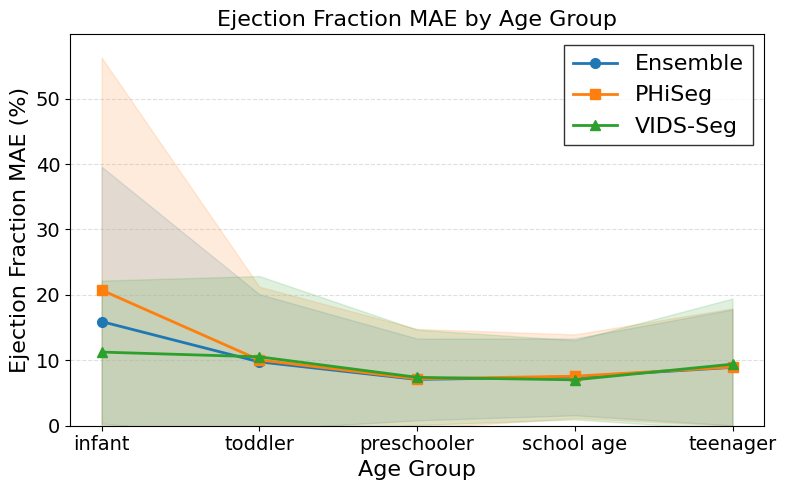

In [28]:
fig, ax = plt.subplots(figsize=(8, 5))

age_groups = stats_ens.index.tolist()
x = np.arange(len(age_groups))

models = {
    'Ensemble': (stats_ens, '#1f77b4', 'o'),
    'PHiSeg':   (stats_phiseg, '#ff7f0e', 's'),
    'VIDS-Seg':     (stats_vids, '#2ca02c', '^'),
}

for name, (stats, color, marker) in models.items():
    mean = stats['mae'].values
    std  = stats['mae_std'].values
    # std = stats['mae_std'].values / np.sqrt(stats['n_samples'].values)

    # shaded std band
    ax.fill_between(x, mean - std, mean + std, alpha=0.15, color=color)
    # mean line
    ax.plot(x, mean, marker=marker, markersize=7, linewidth=2,
            color=color, label=name)

ax.set_xticks(x)
ax.set_xticklabels(age_groups, fontsize=16)
ax.set_xlabel('Age Group', fontsize=16)
ax.set_ylabel('Ejection Fraction MAE (%)', fontsize=16)
ax.set_title('Ejection Fraction MAE by Age Group', fontsize=16)
ax.legend(fontsize=16, frameon=True, fancybox=False, edgecolor='black')
ax.tick_params(labelsize=14)
ax.grid(axis='y', linestyle='--', alpha=0.4)

# Clip shaded bands so they don't go below 0
ax.set_ylim(bottom=0)

# Add sample counts along the bottom
# for i, n in enumerate(stats_ens['n_samples'].values):
#     ax.text(i, ax.get_ylim()[0] + 0.3, f'n={n}', ha='center',
#             fontsize=9, color='grey')

fig.tight_layout()
plt.savefig('ef_mae_by_age_group.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [29]:
from sklearn.metrics import accuracy_score

# Binary classification: reduced EF (EF < 50%) vs. normal, infants only
# Both ground truth and prediction are thresholded at 50%

for name, df in [('Ensemble', df_ef_ens), ('PHiSeg', df_ef_phiseg), ('VIDS-Seg', df_ef_vids)]:
    df_infant = df[df['age_group'] == 'infant']
    y_true = (df_infant['gt_ef'] < 50).astype(int)
    y_pred = (df_infant['mean_ef_pred'] < 50).astype(int)
    acc = accuracy_score(y_true, y_pred)
    n_pos = y_true.sum()
    n_total = len(y_true)
    print(f"{name}: Accuracy = {acc:.3f}  (n_reduced={n_pos}/{n_total})")


Ensemble: Accuracy = 0.783  (n_reduced=8/23)
PHiSeg: Accuracy = 0.739  (n_reduced=8/23)
VIDS-Seg: Accuracy = 0.870  (n_reduced=8/23)


In [30]:
from sklearn.metrics import roc_auc_score

# AUC for reduced EF (EF < 50%) classification, infants only
# Score = -mean_ef_pred so that a lower predicted EF gives a higher probability of reduced EF

for name, df in [('Ensemble', df_ef_ens), ('PHiSeg', df_ef_phiseg), ('VIDS-Seg', df_ef_vids)]:
    df_infant = df[df['age_group'] == 'infant']
    y_true = (df_infant['gt_ef'] < 50).astype(int)
    y_score = -df_infant['mean_ef_pred']
    auc = roc_auc_score(y_true, y_score)
    n_pos = y_true.sum()
    n_total = len(y_true)
    print(f"{name}: AUC = {auc:.3f}  (n_reduced={n_pos}/{n_total})")


Ensemble: AUC = 0.900  (n_reduced=8/23)
PHiSeg: AUC = 0.808  (n_reduced=8/23)
VIDS-Seg: AUC = 0.942  (n_reduced=8/23)
